# Feature Extraction

In [55]:
from pathlib import Path, PurePath
import mne
%matplotlib inline
mne.viz.set_browser_backend("matplotlib")

Using matplotlib as 2D backend.


'qt'

## Load Data

In [59]:
baseline = []
main = []
baseline_fifs = []
main_fifs = []

preprocessed_dir = Path("./../EEG_data/preprocessed/")
# paths for baseline and main folders
baseline_dir = preprocessed_dir / "baseline"
main_dir = preprocessed_dir / "main"

bs_stages = ["eyes closed", "eyes open"]
mn_stages = ["red_screen_0", "reading_1", "red_screen_1", "reading_2",
              "red_screen_2", "reading_3", "red_screen_3", "reading_4", "red_screen_4", "reading_5"]
# populate baseline
for session in baseline_dir.iterdir():
    dict = dict.fromkeys(bs_stages)
    bs_fif = list(session.glob("*.fif"))[0]
    fif = mne.io.read_raw_fif(bs_fif)
    baseline_fifs.append(fif)
    for stage in session.iterdir():
        if stage != bs_fif:
            for fif_file in stage.iterdir():
                fif = mne.read_epochs(fif_file)
                key = PurePath(stage).name
                dict[key] = fif
    baseline.append(dict)
# populate main 
for session in main_dir.iterdir():
    dict = dict.fromkeys(mn_stages)
    mn_fif = list(session.glob("*.fif"))[0]
    fif = mne.io.read_raw_fif(mn_fif)
    main_fifs.append(fif)
    for stage in session.iterdir():
        if stage != mn_fif:
            for fif_file in stage.iterdir():
                fif = mne.read_epochs(fif_file)
                key = PurePath(stage).name
                dict[key] = fif
    main.append(dict)


Opening raw data file ../EEG_data/preprocessed/baseline/2026-04-10_Aminov/2026-04-10_Aminov_raw.fif...
    Range : 0 ... 150167 =      0.000 ...   600.668 secs
Ready.
Reading /Users/fountainer/Downloads/eeg research/eeg-to-code/feature_extraction/../EEG_data/preprocessed/baseline/2026-04-10_Aminov/eyes open/2026-04-10_Aminov_epo.fif ...
    Found the data of interest:
        t =       0.00 ...   14996.00 ms
        0 CTF compensation matrices available
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/fountainer/Downloads/eeg research/eeg-to-code/feature_extraction/../EEG_data/preprocessed/baseline/2026-04-10_Aminov/eyes closed/2026-04-10_Aminov_epo.fif ...
    Found the data of interest:
        t =       0.00 ...   14996.00 ms
        0 CTF compensation matrices available
Not setting metadata
19 matching events found
No baseline correction applied
0 projection items activated
Opening raw data file ../EEG_data/pre

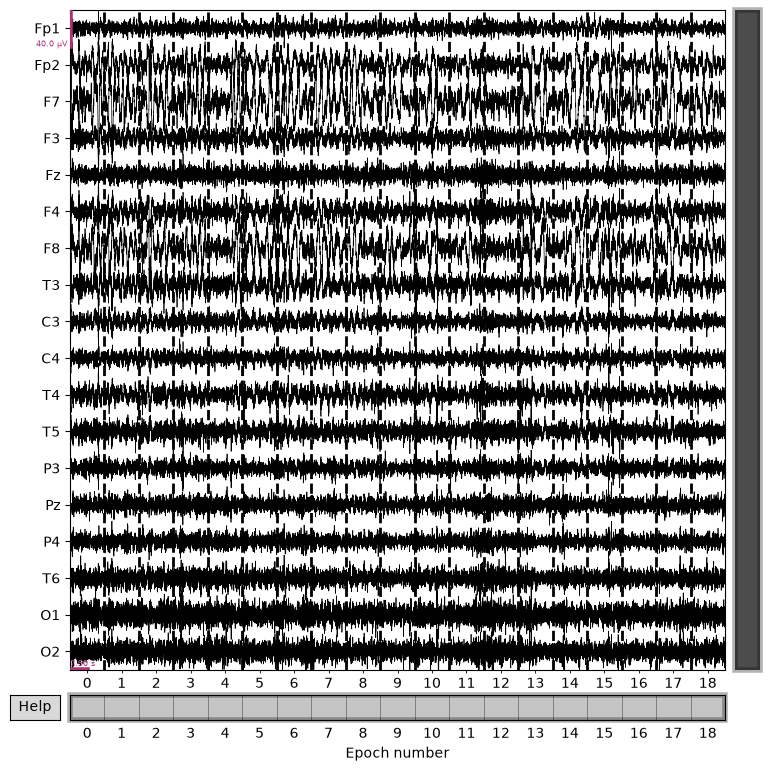

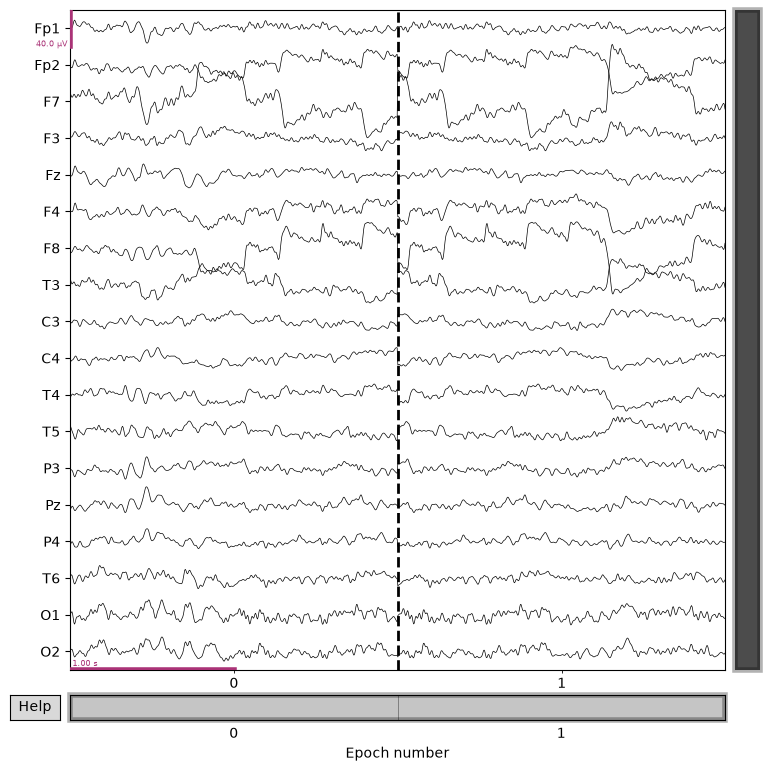

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).


/Users/fountainer/.pyenv/versions/eeg-to-code/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


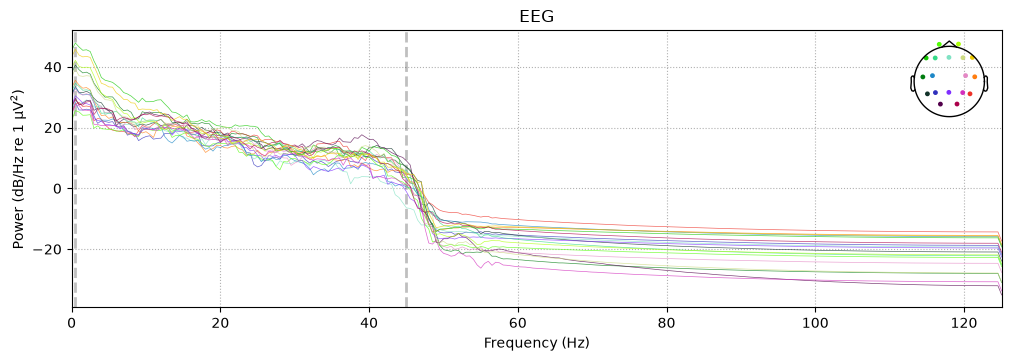

In [68]:
# loaded data examples
baseline[0]["eyes closed"].plot();
main[0]["reading_5"].plot();
main[0]["reading_1"].compute_psd().plot();